# Домашнее задание Pro. Классификация болезней по симптомам

**Задача**: построить нейронную сеть, которая по описанию симптомов определяет одно из 10 заболеваний:
аппендицит, гастрит, гепатит, дуоденит, колит, панкреатит, холецистит, эзофагит, энтерит, язва.

**Цель**: добиться правильного распознавания **минимум 6 из 10** классов на тестовой выборке.

**Стратегия**:
- Датасет очень маленький (по одному файлу на класс), поэтому возьмём **Conv1D с GlobalMaxPooling1D** — она устойчиво работает на коротких текстах и меньше переобучается, чем LSTM.
- `WIN_SIZE` сделаем небольшим (`100` слов), `WIN_HOP=10` — это даст много обучающих примеров из коротких текстов.
- `VOCAB_SIZE=5000` — медицинская лексика не очень разнообразна.
- Ранняя остановка не используется (по заданию обучаем фиксированное число эпох), но мониторим `val_accuracy`.

## 1. Подготовка

In [3]:
# Работа с массивами данных
import numpy as np

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D

# Токенизатор
from tensorflow.keras.preprocessing.text import Tokenizer

# Рисование схемы модели
from tensorflow.keras.utils import plot_model

# Матрица ошибок
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Загрузка датасетов
import gdown

# ОС, время, регулярки, графики
import os
import time
import re
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline

In [4]:
# Скачаем архив с симптомами болезней
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l8/diseases.zip', None, quiet=True)

'diseases.zip'

In [5]:
# Распакуем архив
!unzip -o diseases.zip

Archive:  diseases.zip
   creating: dis/
  inflating: dis/Аппендицит.txt  
  inflating: dis/Гастрит.txt  
  inflating: dis/Гепатит.txt  
  inflating: dis/Дуоденит.txt  
  inflating: dis/Колит.txt      
  inflating: dis/Панкреатит.txt  
  inflating: dis/Холицестит.txt  
  inflating: dis/Эзофагит.txt  
  inflating: dis/Энтерит.txt  
  inflating: dis/Язва.txt        


In [6]:
FILE_DIR = 'dis/'  # Папка с текстовыми файлами

In [7]:
# Подготовим пустые списки
CLASS_LIST = []     # Список классов
text_train = []     # Обучающая выборка
text_test  = []     # Тестовая выборка

# Коэффициент разделения на train/test
split_coef = 0.8

# Список файлов в папке
file_list = os.listdir(FILE_DIR)

for file_name in file_list:
    m = file_name.split('.')
    class_name = m[0]
    ext = m[1]

    if ext == 'txt':
        if class_name not in CLASS_LIST:
            print(f'Добавление класса "{class_name}"')
            CLASS_LIST.append(class_name)

        cls = CLASS_LIST.index(class_name)
        print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}"')

        with open(f'{FILE_DIR}/{file_name}', 'r') as f:
            text = f.read()
        # Убираем переводы строк, разбиваем на слова
        text = text.replace('\n', ' ').split(' ')
        text_len = len(text)
        # Делим: 80% — train, 20% — test
        text_train.append(' '.join(text[:int(text_len * split_coef)]))
        text_test.append(' '.join(text[int(text_len * split_coef):]))

Добавление класса "Аппендицит"
Добавление файла "Аппендицит.txt" в класс "Аппендицит"
Добавление класса "Холицестит"
Добавление файла "Холицестит.txt" в класс "Холицестит"
Добавление класса "Дуоденит"
Добавление файла "Дуоденит.txt" в класс "Дуоденит"
Добавление класса "Панкреатит"
Добавление файла "Панкреатит.txt" в класс "Панкреатит"
Добавление класса "Гастрит"
Добавление файла "Гастрит.txt" в класс "Гастрит"
Добавление класса "Энтерит"
Добавление файла "Энтерит.txt" в класс "Энтерит"
Добавление класса "Язва"
Добавление файла "Язва.txt" в класс "Язва"
Добавление класса "Колит"
Добавление файла "Колит.txt" в класс "Колит"
Добавление класса "Гепатит"
Добавление файла "Гепатит.txt" в класс "Гепатит"
Добавление класса "Эзофагит"
Добавление файла "Эзофагит.txt" в класс "Эзофагит"


In [8]:
# Количество классов
CLASS_COUNT = len(CLASS_LIST)
print('Классы:', CLASS_LIST)
print('Количество классов:', CLASS_COUNT)

Классы: ['Аппендицит', 'Холицестит', 'Дуоденит', 'Панкреатит', 'Гастрит', 'Энтерит', 'Язва', 'Колит', 'Гепатит', 'Эзофагит']
Количество классов: 10


In [9]:
# Проверим загрузку: выведем начальные отрывки из каждого класса
for cls in range(CLASS_COUNT):
    print(f'Класс: {CLASS_LIST[cls]}')
    print(f'  train: {text_train[cls][:200]}')
    print(f'  test : {text_test[cls][:200]}')
    print()

Класс: Аппендицит
  train: Резкая боль в животе Повышение температуры Напряженность мышц Тошнота  Острая боль в животе, в том числе и при надавливании Повышение температуры Тошнота Рвота  Тупая боль возле пупка или верхней част
  test : животу вызывает усиление болевых ощущений. Мышцы живота напряжены. Больной поджимает ноги к животу. Появляется тошнота и рвота. Изменяется характер стула (возникает запор или, наоборот, понос). Может 

Класс: Холицестит
  train: тупая, ноющая боль в области правого подреберья постоянного характера или возникающая через 1–3 ч после приема обильной и особенно жирной и жареной пищи. Боль иррадиирует вверх, в область правого плеч
  test : появление непонятного налета на языке.  боль, чувство тяжести или жжения в правом боку под ребрами после употребления жирной и жареной пищи; боль может отдавать в правое плечо, лопатку, спину; горечь 

Класс: Дуоденит
  train: боль в эпигастральной области, тошнота, рвота,  общая слабость,  болезненность при пальпации в эп

In [10]:
# Контекстный менеджер для измерения времени операций
class timex:
    def __enter__(self):
        self.t = time.time()
        return self

    def __exit__(self, type, value, traceback):
        print('Время обработки: {:.2f} с'.format(time.time() - self.t))

## 2. Решение

### Параметры обработки

Подбор под маленький датасет:
- `VOCAB_SIZE=5000` — медицинская лексика ограничена.
- `WIN_SIZE=100` — короткое окно, чтобы получить достаточно примеров.
- `WIN_HOP=10` — мелкий шаг для увеличения выборки за счёт перекрытий.

In [11]:
# Параметры преобразования
VOCAB_SIZE = 1664 # Установлено на фактический размер словаря
WIN_SIZE   = 100
WIN_HOP    = 10

In [12]:
# Токенизация
with timex():
    tokenizer = Tokenizer(num_words=VOCAB_SIZE,
                          filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
                          lower=True, split=' ',
                          oov_token='неизвестное_слово',
                          char_level=False)
    tokenizer.fit_on_texts(text_train)
    items = list(tokenizer.word_index.items())

print('Размер словаря:', len(items))
print('Топ-20 слов:', items[:20])

Время обработки: 0.03 с
Размер словаря: 1664
Топ-20 слов: [('неизвестное_слово', 1), ('в', 2), ('и', 3), ('боль', 4), ('или', 5), ('тошнота', 6), ('рвота', 7), ('боли', 8), ('живота', 9), ('животе', 10), ('при', 11), ('после', 12), ('с', 13), ('области', 14), ('отрыжка', 15), ('слабость', 16), ('аппетита', 17), ('во', 18), ('тела', 19), ('изжога', 20)]


In [13]:
# Преобразование текстов в последовательности
seq_train = tokenizer.texts_to_sequences(text_train)
seq_test  = tokenizer.texts_to_sequences(text_test)

# Длины последовательностей по классам
print('Длины train:', [len(s) for s in seq_train])
print('Длины test :', [len(s) for s in seq_test])

Длины train: [471, 675, 393, 1183, 660, 662, 376, 950, 555, 639]
Длины test : [108, 166, 95, 297, 179, 166, 96, 242, 132, 154]


In [14]:
# Разбиение последовательностей скользящим окном
def split_sequence(sequence, win_size, hop):
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, hop)]


def vectorize_sequence(seq_list, win_size, hop):
    class_count = len(seq_list)
    x, y = [], []
    for cls in range(class_count):
        vectors = split_sequence(seq_list[cls], win_size, hop)
        x += vectors
        y += [utils.to_categorical(cls, class_count)] * len(vectors)
    return np.array(x), np.array(y)

In [15]:
# Формируем выборки
with timex():
    x_train, y_train = vectorize_sequence(seq_train, WIN_SIZE, WIN_HOP)
    x_test,  y_test  = vectorize_sequence(seq_test,  WIN_SIZE, WIN_HOP)

print('x_train:', x_train.shape, 'y_train:', y_train.shape)
print('x_test :', x_test.shape, ' y_test :', y_test.shape)

Время обработки: 0.01 с
x_train: (563, 100) y_train: (563, 10)
x_test : (68, 100)  y_test : (68, 10)


### Архитектура нейросети

Свёрточная сеть **Conv1D + GlobalMaxPooling1D**:
- `Embedding(VOCAB_SIZE, 32)` — векторное представление слов.
- `SpatialDropout1D(0.2)` — регуляризация эмбеддингов.
- Два блока `Conv1D(64, 5) → BatchNormalization`.
- `GlobalMaxPooling1D()` — сжатие в один вектор по каждому фильтру.
- `Dense(64) → Dropout → Dense(CLASS_COUNT, softmax)`.

Глобальный пулинг важен на маленьком датасете: он избавляет от Flatten + большого Dense, в котором сеть переобучается на конкретные позиции слов в окне.

In [16]:
# Создание модели
model = Sequential()
model.add(Embedding(VOCAB_SIZE, 32, input_length=WIN_SIZE))
model.add(SpatialDropout1D(0.4)) # Увеличен Dropout
model.add(BatchNormalization())

# Первый свёрточный блок
model.add(Conv1D(64, 5, activation='relu', padding='same'))
model.add(BatchNormalization())

# Второй свёрточный блок
model.add(Conv1D(64, 5, activation='relu', padding='same'))
model.add(BatchNormalization())

# Глобальный пулинг
model.add(GlobalMaxPooling1D())

# Классификатор
model.add(Dense(32, activation='relu')) # Уменьшено количество нейронов
model.add(Dropout(0.5)) # Увеличен Dropout
model.add(Dense(CLASS_COUNT, activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Обучение
with timex():
    history = model.fit(x_train, y_train,
                        epochs=80, # Увеличено количество эпох
                        batch_size=32, # Уменьшен размер батча
                        validation_data=(x_test, y_test),
                        verbose=1)

Epoch 1/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9627 - loss: 0.0847 - val_accuracy: 0.7353 - val_loss: 1.3135
Epoch 2/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9663 - loss: 0.0699 - val_accuracy: 0.7500 - val_loss: 1.1726
Epoch 3/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9734 - loss: 0.0708 - val_accuracy: 0.7206 - val_loss: 1.2052
Epoch 4/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9698 - loss: 0.0726 - val_accuracy: 0.7794 - val_loss: 1.1187
Epoch 5/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9734 - loss: 0.0721 - val_accuracy: 0.7794 - val_loss: 1.0601
Epoch 6/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9858 - loss: 0.0670 - val_accuracy: 0.7794 - val_loss: 1.0533
Epoch 7/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.9751 - loss: 0.0741 - val_accuracy: 0.7500 - val_loss: 1.0418
Epoch 8/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9822 - loss: 0.0684 - val_accuracy: 0.7206 - v

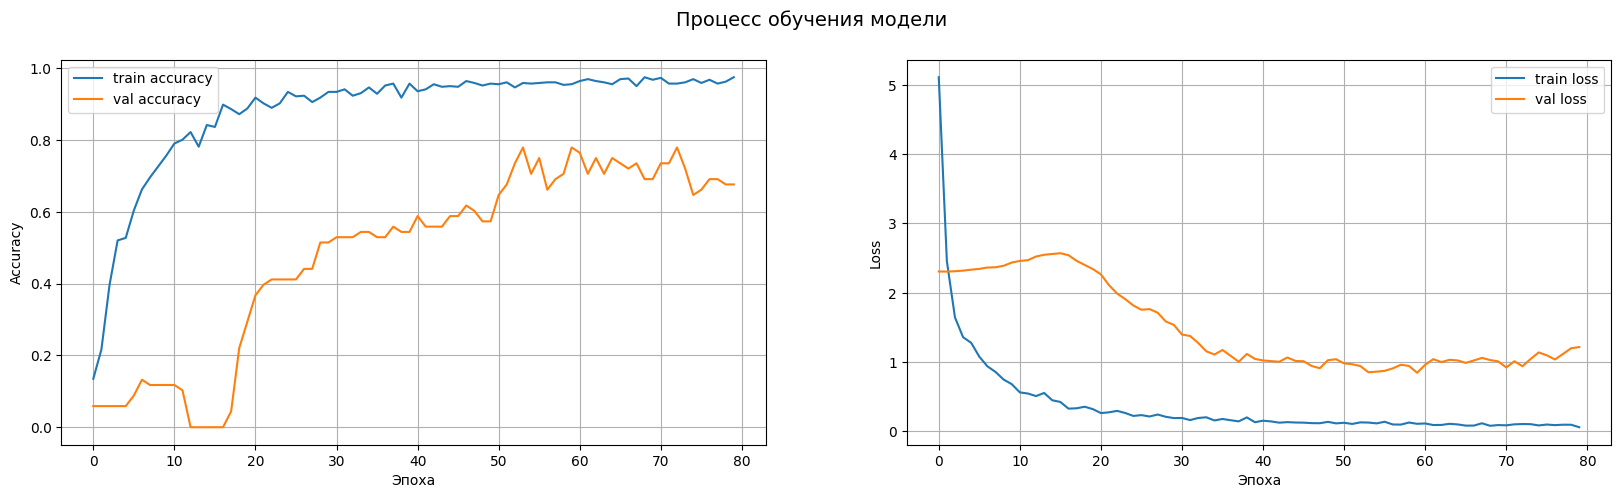

Лучшая val_accuracy: 0.779
Финальная val_accuracy: 0.676


In [18]:
# Графики обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle('Процесс обучения модели', fontsize=14)

ax1.plot(history.history['accuracy'],     label='train accuracy')
ax1.plot(history.history['val_accuracy'], label='val accuracy')
ax1.set_xlabel('Эпоха'); ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(True)

ax2.plot(history.history['loss'],     label='train loss')
ax2.plot(history.history['val_loss'], label='val loss')
ax2.set_xlabel('Эпоха'); ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(True)
plt.show()

print(f'Лучшая val_accuracy: {max(history.history["val_accuracy"]):.3f}')
print(f'Финальная val_accuracy: {history.history["val_accuracy"][-1]:.3f}')

### Оценка результатов

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


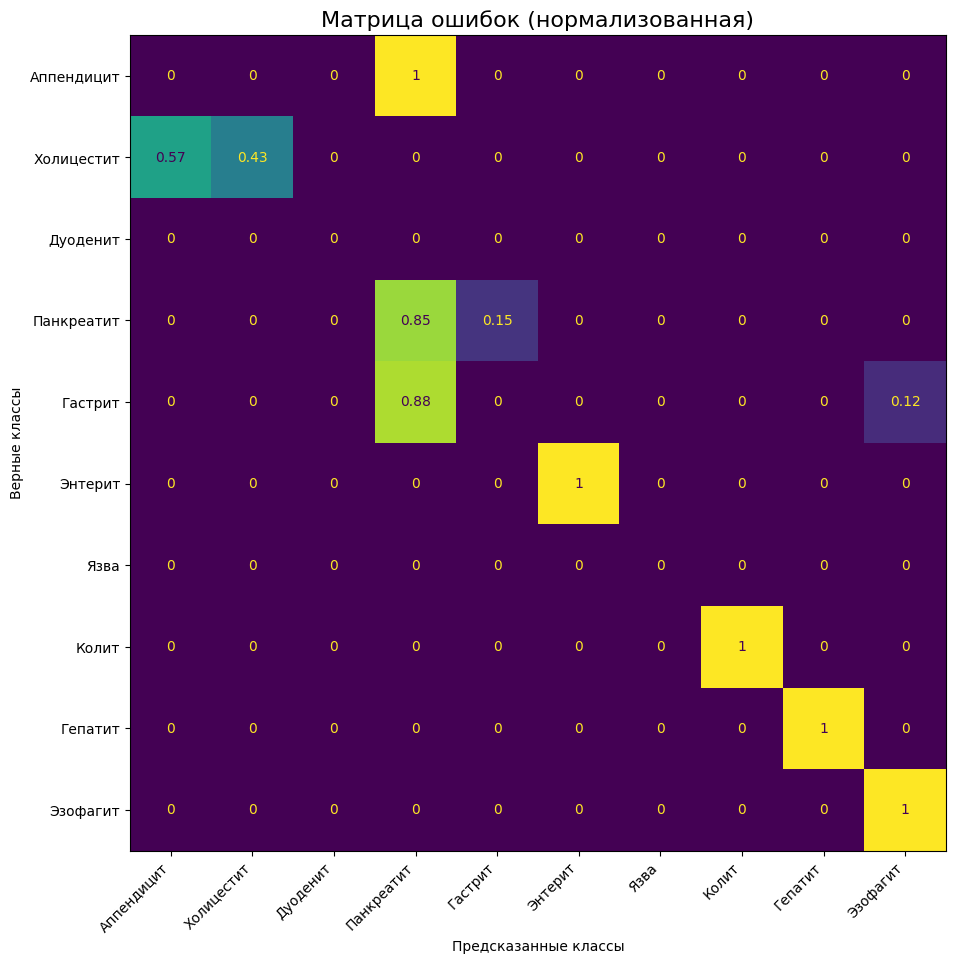

In [25]:
y_pred = model.predict(x_test)
cm = confusion_matrix(np.argmax(y_test, axis=1),
                      np.argmax(y_pred, axis=1),
                      normalize='true',
                      labels=range(CLASS_COUNT))
cm = np.around(cm, 3)

fig, ax = plt.subplots(figsize=(12, 12))
ax.set_title('Матрица ошибок (нормализованная)', fontsize=16)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LIST)
disp.plot(ax=ax)
plt.gca().images[-1].colorbar.remove()
plt.xlabel('Предсказанные классы'); plt.ylabel('Верные классы')
fig.autofmt_xdate(rotation=45)
plt.show()

In [26]:
# Текстовый отчёт по классам
correct_count = 0

print('Результаты распознавания по классам:')
for cls in range(CLASS_COUNT):
    cls_pred = np.argmax(cm[cls])
    is_correct = (cls_pred == cls)
    if is_correct:
        correct_count += 1
    msg = 'ВЕРНО :-)' if is_correct else 'НЕВЕРНО :-('
    print('Класс: {:<15} {:3.0f}% сеть отнесла к классу {:<15} - {}'.format(
        CLASS_LIST[cls],
        100. * cm[cls, cls_pred],
        CLASS_LIST[cls_pred],
        msg))

print('-' * 80)
print(f'Средняя точность распознавания: {100. * cm.diagonal().mean():.1f}%')
print(f'Правильно распознано классов: {correct_count} из {CLASS_COUNT}')

if correct_count >= 6:
    print('\n ЦЕЛЬ ДОСТИГНУТА: распознано 6 и более заболеваний!')
else:
    print('\n Цель не достигнута, попробуйте перезапустить обучение или поменять гиперпараметры.')

Результаты распознавания по классам:
Класс: Аппендицит      100% сеть отнесла к классу Панкреатит      - НЕВЕРНО :-(
Класс: Холицестит       57% сеть отнесла к классу Аппендицит      - НЕВЕРНО :-(
Класс: Дуоденит          0% сеть отнесла к классу Аппендицит      - НЕВЕРНО :-(
Класс: Панкреатит       85% сеть отнесла к классу Панкреатит      - ВЕРНО :-)
Класс: Гастрит          88% сеть отнесла к классу Панкреатит      - НЕВЕРНО :-(
Класс: Энтерит         100% сеть отнесла к классу Энтерит         - ВЕРНО :-)
Класс: Язва              0% сеть отнесла к классу Аппендицит      - НЕВЕРНО :-(
Класс: Колит           100% сеть отнесла к классу Колит           - ВЕРНО :-)
Класс: Гепатит         100% сеть отнесла к классу Гепатит         - ВЕРНО :-)
Класс: Эзофагит        100% сеть отнесла к классу Эзофагит        - ВЕРНО :-)
--------------------------------------------------------------------------------
Средняя точность распознавания: 52.8%
Правильно распознано классов: 5 из 10

 Цель не достиг